In [1]:
from dtw import *
import numpy as np
import datetime
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import statistics

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
# importing the libraries
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import tensorflow_probability as tfp
print(tf.reduce_sum(tf.random.normal([1000, 1000])))
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from keras.models import load_model

tf.Tensor(-7.8078613, shape=(), dtype=float32)


2024-05-17 22:04:43.647844: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# reading your file for Wind data
Wind_read_file = pd.read_csv("WI_H1_SWE_2017.csv", delimiter = ',', comment='#', \
                    parse_dates=[0], infer_datetime_format=True, na_values='-1.00000e+31') #  by convention we call it "df
Wind_read_file = Wind_read_file.rename(columns={Wind_read_file.columns[0]:"Epoch", Wind_read_file.columns[1]:"PROTON_BULK_SPEED", Wind_read_file.columns[2]:"P+_W_NONLIN", Wind_read_file.columns[3]:"P+_DENSITY", Wind_read_file.columns[4]:"BX", Wind_read_file.columns[5]:"BY", Wind_read_file.columns[6]:"BZ"})

Wind_read_file


,Epoch,PROTON_BULK_SPEED,P+_W_NONLIN,P+_DENSITY,BX,BY,BZ
0,2017-01-01 00:01:21.143000+00:00,551.383,56.4392,6.90979,-6.23286,3.663370,-0.618211
1,2017-01-01 00:03:00.041000+00:00,548.496,53.7259,6.90203,-6.38386,2.677510,-1.543220
2,2017-01-01 00:04:38.940000+00:00,553.285,57.2532,7.52417,-5.17778,-3.331740,-3.239950
3,2017-01-01 00:06:17.838000+00:00,568.129,51.5084,7.31016,-3.61870,-4.982880,-3.905190
4,2017-01-01 00:07:56.737000+00:00,550.258,54.0437,6.99562,-5.84033,-1.151720,-3.860940
...,...,...,...,...,...,...,...
302714,2017-12-31 23:50:55.302000+00:00,389.247,54.0795,16.26670,0.74707,-0.888578,-5.844250
302715,2017-12-31 23:52:34.309000+00:00,395.178,43.1694,15.22750,2.03863,-1.143950,-6.759960
302716,2017-12-31 23:54:13.317000+00:00,397.280,38.6794,13.12920,4.09914,-3.528210,-7.518280
302717,2017-12-31 23:55:52.325000+00:00,396.026,38.2271,13.32620,4.87532,-3.791930,-7.872770


In [4]:
Wind_read_file_drop=Wind_read_file.dropna() #deleting nan values
Wind_read_file_drop

,Epoch,PROTON_BULK_SPEED,P+_W_NONLIN,P+_DENSITY,BX,BY,BZ
0,2017-01-01 00:01:21.143000+00:00,551.383,56.4392,6.90979,-6.23286,3.663370,-0.618211
1,2017-01-01 00:03:00.041000+00:00,548.496,53.7259,6.90203,-6.38386,2.677510,-1.543220
2,2017-01-01 00:04:38.940000+00:00,553.285,57.2532,7.52417,-5.17778,-3.331740,-3.239950
3,2017-01-01 00:06:17.838000+00:00,568.129,51.5084,7.31016,-3.61870,-4.982880,-3.905190
4,2017-01-01 00:07:56.737000+00:00,550.258,54.0437,6.99562,-5.84033,-1.151720,-3.860940
...,...,...,...,...,...,...,...
302714,2017-12-31 23:50:55.302000+00:00,389.247,54.0795,16.26670,0.74707,-0.888578,-5.844250
302715,2017-12-31 23:52:34.309000+00:00,395.178,43.1694,15.22750,2.03863,-1.143950,-6.759960
302716,2017-12-31 23:54:13.317000+00:00,397.280,38.6794,13.12920,4.09914,-3.528210,-7.518280
302717,2017-12-31 23:55:52.325000+00:00,396.026,38.2271,13.32620,4.87532,-3.791930,-7.872770


In [5]:
#keeping only values within the right range
Wind_read_file_drop =Wind_read_file_drop[Wind_read_file_drop["P+_DENSITY"].between(0.1, 50)]  #density values
Wind_read_file_drop = Wind_read_file_drop[Wind_read_file_drop["P+_W_NONLIN"].between(10, 150)]  #Temperature values
Wind_read_file_drop = Wind_read_file_drop[Wind_read_file_drop["PROTON_BULK_SPEED"].between(200, 900)]  #speed values

Wind_read_file_drop = Wind_read_file_drop[Wind_read_file_drop["BX"].between(-100, 100)]
Wind_read_file_drop = Wind_read_file_drop[Wind_read_file_drop["BY"].between(-100, 100)]
Wind_read_file_drop = Wind_read_file_drop[Wind_read_file_drop["BZ"].between(-100, 100)]


# -100 < Bx < 100
# -100 < By < 100
# -100 < Bz < 100
# 200 < proton speed < 900
# 10 < proton thermal speed < 150
# 0.1 < proton density < 50


In [6]:
Wind_read_file_drop.to_csv("WI_H1_SWE_2017_final.csv", index=False) # save your new csv file

In [7]:
#reading your new CSV file for Wind data
wdata_read = pd.read_csv("WI_H1_SWE_2017_final.csv", delimiter = ',', comment='#', \
                    parse_dates=[0],infer_datetime_format=True, date_parser=lambda col: pd.to_datetime(col, utc=True),na_values='-1.00000e+31')
wdata_read = wdata_read.rename(columns={wdata_read.columns[0]:"Epoch_time", wdata_read.columns[1]:"Speed", wdata_read.columns[2]:"Temp", wdata_read.columns[3]:"Density", wdata_read.columns[4]:"bx", wdata_read.columns[5]:"by", wdata_read.columns[6]:"bz"})
wdata_read

,Epoch_time,Speed,Temp,Density,bx,by,bz
0,2017-01-01 00:01:21.143000+00:00,551.383,56.4392,6.90979,-6.23286,3.663370,-0.618211
1,2017-01-01 00:03:00.041000+00:00,548.496,53.7259,6.90203,-6.38386,2.677510,-1.543220
2,2017-01-01 00:04:38.940000+00:00,553.285,57.2532,7.52417,-5.17778,-3.331740,-3.239950
3,2017-01-01 00:06:17.838000+00:00,568.129,51.5084,7.31016,-3.61870,-4.982880,-3.905190
4,2017-01-01 00:07:56.737000+00:00,550.258,54.0437,6.99562,-5.84033,-1.151720,-3.860940
...,...,...,...,...,...,...,...
285956,2017-12-31 23:50:55.302000+00:00,389.247,54.0795,16.26670,0.74707,-0.888578,-5.844250
285957,2017-12-31 23:52:34.309000+00:00,395.178,43.1694,15.22750,2.03863,-1.143950,-6.759960
285958,2017-12-31 23:54:13.317000+00:00,397.280,38.6794,13.12920,4.09914,-3.528210,-7.518280
285959,2017-12-31 23:55:52.325000+00:00,396.026,38.2271,13.32620,4.87532,-3.791930,-7.872770


In [8]:
#reading DSCOVR data
ddata_read = pd.read_csv("dsc_fc_summed_spectra_2017_v01.csv", delimiter = ',', comment='#', \
                  parse_dates=[0], infer_datetime_format=True, na_values='-1.00000e+31')


In [9]:
zero_mask = (((ddata_read.iloc[:,4:54]).values) == 0).all(axis=1)

ddata_to_filter = ddata_read[~zero_mask]
ddata_to_filter

,2017-01-01 00:00:00,-4.17863,-4.51183,-3.52434,0,0.1,0.2,0.3,0.4,0.5,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
0,2017-01-01 00:01:00,-6.06788,-0.379552,-3.49708,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-01-01 00:02:00,-5.83430,-3.039940,-2.98546,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-01-01 00:03:00,-5.87318,-3.352910,-2.77476,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017-01-01 00:04:00,-5.81431,-3.305190,-2.59870,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017-01-01 00:05:00,-6.23986,-3.240720,-1.01048,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525594,2017-12-31 23:55:00,6.07246,-3.402390,-4.20657,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525595,2017-12-31 23:56:00,6.94467,-3.434060,-4.33012,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525596,2017-12-31 23:57:00,7.04210,-1.602740,-5.85800,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525597,2017-12-31 23:58:00,6.74641,0.337871,-6.33095,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
wdata_read = wdata_read.resample('160s', on='Epoch_time').median()

wdata = wdata_read.interpolate(method="linear")  #interpolating to fill in data gaps in Wind data
wdata

,Speed,Temp,Density,bx,by,bz
Epoch_time,,,,,,
2017-01-01 00:00:00+00:00,551.3830,56.43920,6.909790,-6.232860,3.663370,-0.618211
2017-01-01 00:02:40+00:00,550.8905,55.48955,7.213100,-5.780820,-0.327115,-2.391585
2017-01-01 00:05:20+00:00,559.1935,52.77605,7.152890,-4.729515,-3.067300,-3.883065
2017-01-01 00:08:00+00:00,550.6040,55.52160,7.671590,-5.797990,-2.731430,-3.537750
2017-01-01 00:10:40+00:00,551.8050,53.21985,7.028765,-5.739440,-3.250100,-3.133550
...,...,...,...,...,...,...
2017-12-31 23:46:40+00:00,391.1725,44.63585,14.160100,2.752630,-3.058350,-7.148715
2017-12-31 23:49:20+00:00,389.2470,54.07950,16.266700,0.747070,-0.888578,-5.844250
2017-12-31 23:52:00+00:00,396.2290,40.92440,14.178350,3.068885,-2.336080,-7.139120


In [11]:
ddata_read_drop=ddata_to_filter.dropna() #deleting nan values

In [12]:
ddata_read_drop

,2017-01-01 00:00:00,-4.17863,-4.51183,-3.52434,0,0.1,0.2,0.3,0.4,0.5,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
0,2017-01-01 00:01:00,-6.06788,-0.379552,-3.49708,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-01-01 00:02:00,-5.83430,-3.039940,-2.98546,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-01-01 00:03:00,-5.87318,-3.352910,-2.77476,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017-01-01 00:04:00,-5.81431,-3.305190,-2.59870,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017-01-01 00:05:00,-6.23986,-3.240720,-1.01048,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525594,2017-12-31 23:55:00,6.07246,-3.402390,-4.20657,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525595,2017-12-31 23:56:00,6.94467,-3.434060,-4.33012,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525596,2017-12-31 23:57:00,7.04210,-1.602740,-5.85800,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525597,2017-12-31 23:58:00,6.74641,0.337871,-6.33095,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
ddata_read_drop = ddata_read_drop.rename(columns={ddata_read_drop.columns[0]:"t", ddata_read_drop.columns[1]:"bx", ddata_read_drop.columns[2]:"by",ddata_read_drop.columns[3]:"bz"})
ddata_read_drop = ddata_read_drop.resample('160s', on='t').median()
ddata_read_drop

,bx,by,bz,0,0.1,0.2,0.3,0.4,0.5,0.6,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
t,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,-5.951090,-1.709746,-3.241270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:02:40,-5.873180,-3.305190,-2.598700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:05:20,-5.737460,-3.549605,-2.038740,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:08:00,-5.741180,-2.831990,-3.252300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:10:40,-5.658680,-2.894970,-3.115560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 23:46:40,4.976460,-4.971770,-5.477130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-12-31 23:49:20,2.926140,-3.184660,-6.830780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-12-31 23:52:00,2.161340,-1.924160,-3.708310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
ddata = ddata_read_drop.interpolate(method="linear") #interpolation for DSCOVR data
ddata

,bx,by,bz,0,0.1,0.2,0.3,0.4,0.5,0.6,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
t,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,-5.951090,-1.709746,-3.241270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:02:40,-5.873180,-3.305190,-2.598700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:05:20,-5.737460,-3.549605,-2.038740,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:08:00,-5.741180,-2.831990,-3.252300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:10:40,-5.658680,-2.894970,-3.115560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 23:46:40,4.976460,-4.971770,-5.477130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-12-31 23:49:20,2.926140,-3.184660,-6.830780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-12-31 23:52:00,2.161340,-1.924160,-3.708310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
wdata

,Speed,Temp,Density,bx,by,bz
Epoch_time,,,,,,
2017-01-01 00:00:00+00:00,551.3830,56.43920,6.909790,-6.232860,3.663370,-0.618211
2017-01-01 00:02:40+00:00,550.8905,55.48955,7.213100,-5.780820,-0.327115,-2.391585
2017-01-01 00:05:20+00:00,559.1935,52.77605,7.152890,-4.729515,-3.067300,-3.883065
2017-01-01 00:08:00+00:00,550.6040,55.52160,7.671590,-5.797990,-2.731430,-3.537750
2017-01-01 00:10:40+00:00,551.8050,53.21985,7.028765,-5.739440,-3.250100,-3.133550
...,...,...,...,...,...,...
2017-12-31 23:46:40+00:00,391.1725,44.63585,14.160100,2.752630,-3.058350,-7.148715
2017-12-31 23:49:20+00:00,389.2470,54.07950,16.266700,0.747070,-0.888578,-5.844250
2017-12-31 23:52:00+00:00,396.2290,40.92440,14.178350,3.068885,-2.336080,-7.139120


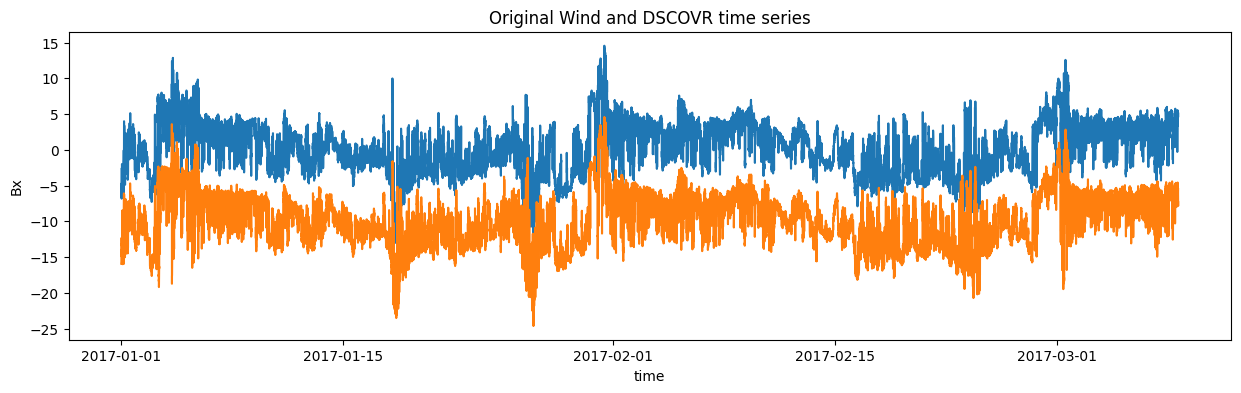

In [16]:
# Plot the two time series pre-warping. They look very similar already
f = plt.figure()
f.set_figwidth(15)
f.set_figheight(4)

plt.plot(wdata['bx'][0:36000])  #only selecting few months of data for now
plt.title('Original Wind and DSCOVR time series')
plt.xlabel('time')
plt.ylabel('Bx')
plt.plot(ddata['bx'][0:36000]-10)


In [17]:
#reading DSCOVR data
#col_names = ["EPOCH__yyyy-mm-ddThh:mm:ss.sssZ", "SW_VTH__km/s_(w/o_error_bars)", "ION_N__#/cc_(w/o_error_bars)", "VX_(GSE)_(@_x_)_km/s_(w/o_error_bars)", "VY_(GSE)_(@_y_)_km/s_(w/o_error_bars)", "VZ_(GSE)_(@_z_)_km/s_(w/o_error_bars)"]
ddata_read_science = pd.read_csv("DSCOVR_H1_FC_2017_nvT_1minute.csv", delimiter = ',',index_col=False, comment='#', \
                  parse_dates=[0], infer_datetime_format=True, na_values='-1.00000e+31')
ddata_read_science


,EPOCH__yyyy-mm-ddThh:mm:ss.sssZ,wp,np,vp
0,2017-01-01 00:00:00+00:00,55.8827,6.41355,548.235
1,2017-01-01 00:01:00+00:00,49.2905,5.81441,533.246
2,2017-01-01 00:02:00+00:00,50.0845,6.11847,536.926
3,2017-01-01 00:03:00+00:00,49.9076,6.16366,537.169
4,2017-01-01 00:04:00+00:00,49.6466,5.99470,536.550
...,...,...,...,...
516955,2017-12-31 23:54:59+00:00,42.7539,16.78620,400.728
516956,2017-12-31 23:56:00+00:00,42.3851,16.45130,401.399
516957,2017-12-31 23:57:01+00:00,38.9540,16.52870,400.209
516958,2017-12-31 23:57:59+00:00,38.7463,16.11450,402.689


In [18]:
ddata_read_science_drop=ddata_read_science.dropna() #deleting nan values
ddata_read_science_drop

,EPOCH__yyyy-mm-ddThh:mm:ss.sssZ,wp,np,vp
0,2017-01-01 00:00:00+00:00,55.8827,6.41355,548.235
1,2017-01-01 00:01:00+00:00,49.2905,5.81441,533.246
2,2017-01-01 00:02:00+00:00,50.0845,6.11847,536.926
3,2017-01-01 00:03:00+00:00,49.9076,6.16366,537.169
4,2017-01-01 00:04:00+00:00,49.6466,5.99470,536.550
...,...,...,...,...
516955,2017-12-31 23:54:59+00:00,42.7539,16.78620,400.728
516956,2017-12-31 23:56:00+00:00,42.3851,16.45130,401.399
516957,2017-12-31 23:57:01+00:00,38.9540,16.52870,400.209
516958,2017-12-31 23:57:59+00:00,38.7463,16.11450,402.689


In [19]:
ddata_read_science_drop = ddata_read_science_drop.rename(columns={ddata_read_science_drop.columns[0]:"epoch", ddata_read_science_drop.columns[1]:"wp", ddata_read_science_drop.columns[2]:"np", ddata_read_science_drop.columns[3]:"vp"})
ddata_read_science_drop

,epoch,wp,np,vp
0,2017-01-01 00:00:00+00:00,55.8827,6.41355,548.235
1,2017-01-01 00:01:00+00:00,49.2905,5.81441,533.246
2,2017-01-01 00:02:00+00:00,50.0845,6.11847,536.926
3,2017-01-01 00:03:00+00:00,49.9076,6.16366,537.169
4,2017-01-01 00:04:00+00:00,49.6466,5.99470,536.550
...,...,...,...,...
516955,2017-12-31 23:54:59+00:00,42.7539,16.78620,400.728
516956,2017-12-31 23:56:00+00:00,42.3851,16.45130,401.399
516957,2017-12-31 23:57:01+00:00,38.9540,16.52870,400.209
516958,2017-12-31 23:57:59+00:00,38.7463,16.11450,402.689


In [20]:
ddata_read_science_drop = ddata_read_science_drop.resample('160s', on='epoch').median()#.bfill()
ddata_science = ddata_read_science_drop.interpolate(method="linear") #interpolation for DSCOVR data
ddata_science

,wp,np,vp
epoch,,,
2017-01-01 00:00:00+00:00,50.08450,6.11847,536.9260
2017-01-01 00:02:40+00:00,49.64660,5.99470,536.5500
2017-01-01 00:05:20+00:00,49.63445,5.88859,536.8850
2017-01-01 00:08:00+00:00,48.93990,5.64802,535.7550
2017-01-01 00:10:40+00:00,49.98810,5.77130,536.1600
...,...,...,...
2017-12-31 23:46:40+00:00,45.96960,15.88040,390.9050
2017-12-31 23:49:20+00:00,45.99665,15.56725,388.2120
2017-12-31 23:52:00+00:00,50.29290,16.02590,389.4080


### first part: Dynamic Time Warping

In [21]:
def DTW_function(wdata_input, ddata_input, start_index, end_index):
  
    query1_ = wdata_input.bx.values[start_index:end_index]  #WIND
    #query2 = adata.bx.values[0:3599]  #ACE
    template_ = ddata_input.bx.values[start_index:end_index] #DSCOVR as reference


    alignment_wd_ = dtw(query1_, template_, keep_internals=True, step_pattern=rabinerJuangStepPattern(6, "c"))
    #alignment_ad = dtw(query2, template, keep_internals=True)

    ## Display the warping curve, i.e. the alignment curve
    #alignment_wd_plot=alignment_wd.plot(type="threeway", xlab='Wind time base in minutes', ylab='DSCOVR time base in minutes', main='PLot title')
    #alignment_ad.plot(type="threeway")

    ## Align and plot with the Rabiner-Juang type VI-c unsmoothed recursion...
    
    #dtw_map=dtw(query1, template, keep_internals=True, 
        #step_pattern=rabinerJuangStepPattern(6, "c")).plot(type="twoway",xlab='nT', ylab='nT DSC',offset=-10) #blue color is the reference(DSCOVR in this case) 

    #dtw(query2, template, keep_internals=True, 
        #step_pattern=rabinerJuangStepPattern(6, "c")).plot(type="twoway",offset=-10) 

    ## See the recursion relation, as formula and diagram
    #print(rabinerJuangStepPattern(6,"c"))
    #rabinerJuangStepPattern(6,"c").plot()
    ind = warp(alignment_wd_,index_reference=False)  #indexing here #which is the indexing from the dtw part above
    
    return query1_, template_, alignment_wd_, ind

In [22]:
query1, template, alignment_wd, ind_Jan_Feb=DTW_function(wdata, ddata, 0, 36000)

Text(0.5, 1.0, 'Wind and DSCOVR Bx time series pre-warping')

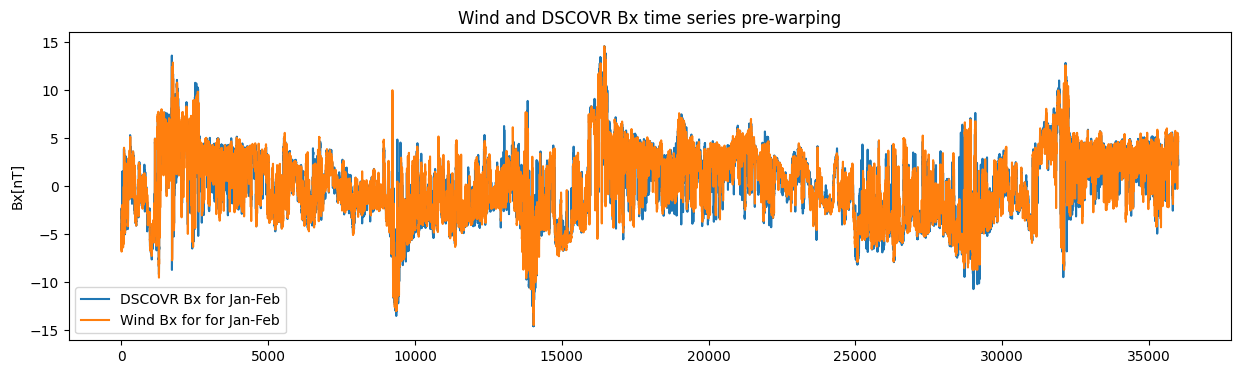

In [23]:
# plot the original Bx time series data all on top of each other
f = plt.figure()
f.set_figwidth(15)
f.set_figheight(4)
plt.plot(template, label='DSCOVR Bx for Jan-Feb')
plt.plot(query1, label='Wind Bx for for Jan-Feb')
#plt.plot(query2)
plt.ylabel('Bx[nT]')
plt.legend()
plt.title('Wind and DSCOVR Bx time series pre-warping')

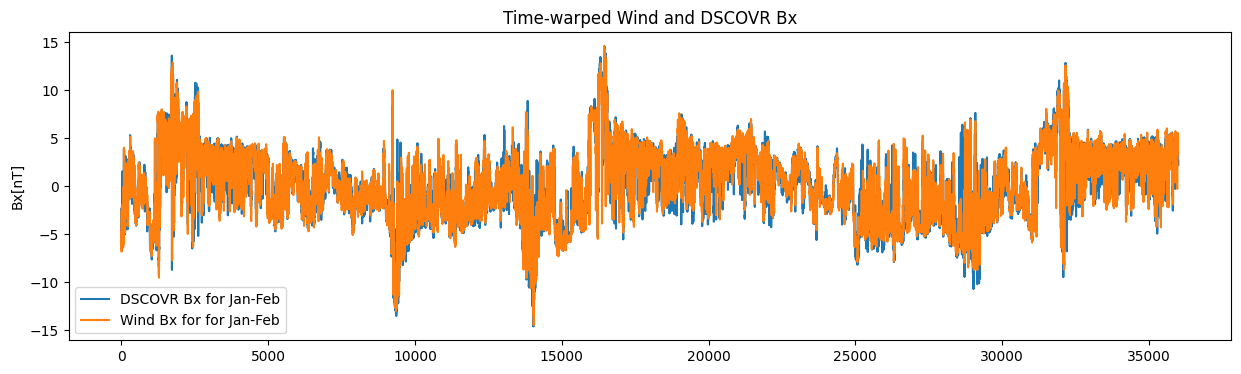

In [24]:
#replot the previous, with time warped version
f = plt.figure()
f.set_figwidth(15)
f.set_figheight(4)
plt.plot(template, label='DSCOVR Bx for Jan-Feb') #DSCOVR
plt.plot(query1[ind_Jan_Feb], label='Wind Bx for for Jan-Feb') #Wind time-warped
plt.title('Time-warped Wind and DSCOVR Bx')
plt.legend()
#plt.plot(query2[ind2])
#plt.xlabel('time')
plt.ylabel('Bx[nT]')
plt.show()

## second step: time warping

In [25]:
def warp_function(wdata_input, ind):
    
    Wind_density_=wdata_input['Density']
    Wind_Temp_=wdata_input['Temp']
    Wind_speed_=wdata_input['Speed']

    
    warped_density_=Wind_density_[ind]  
    warped_temp_=Wind_Temp_[ind]
    warped_speed_=Wind_speed_[ind]
    return warped_density_, warped_temp_, warped_speed_

In [26]:
warped_density_Jan_Feb, warped_temp_Jan_Feb, warped_speed_Jan_Feb=warp_function(wdata, ind_Jan_Feb)

## Final step: Neural Network model

In [27]:
# importing the libraries
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import tensorflow_probability as tfp
print(tf.reduce_sum(tf.random.normal([1000, 1000])))
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from keras.models import load_model

tf.Tensor(510.9362, shape=(), dtype=float32)


In [28]:
def input_prep_func(ddata_input, warped_speed, index_start, index_end):
    X = (ddata_input.iloc[:,3:53]).values  #DSCOVR data columns 3:53 as the X input
    Y = np.transpose([warped_speed]) #warped wind as the y input


    DSCOVR_input_=X[index_start:(index_end),:]  #DSCOVR selecting a smaller chunk to work with, Jan-Feb
    Wind_input_=Y[index_start:index_end]
    return DSCOVR_input_, Wind_input_

In [29]:
DSCOVR_input_Jan_Feb, Wind_input_Jan_Feb=input_prep_func(ddata, warped_speed_Jan_Feb, 0, 36000)

In [30]:
def standardization_func(DSCOVR_input,  Wind_input):

    PredictorScaler=StandardScaler()
    TargetVarScaler=StandardScaler()

    # Storing the fit object for later reference
    PredictorScalerFit_=PredictorScaler.fit(DSCOVR_input)
    TargetVarScalerFit_=TargetVarScaler.fit(Wind_input)

    # Generating the standardized values of DSCOVR_input and Wind_input
    DSCOVR_input_final=PredictorScalerFit_.transform(DSCOVR_input)
    Wind_input_final=TargetVarScalerFit_.transform(Wind_input)

    # Split the data into training and testing set
    
    DSCOVR_input_train, DSCOVR_input_test, Wind_input_train, Wind_input_test = train_test_split(DSCOVR_input_final, Wind_input_final, test_size=0.3, random_state=42)

    # Quick sanity check with the shapes of Training and testing datasets
    print(DSCOVR_input_train.shape)
    print(Wind_input_train.shape)
    print(DSCOVR_input_test.shape)
    print(Wind_input_test.shape)
    
    return PredictorScalerFit_, TargetVarScalerFit_, DSCOVR_input_final, Wind_input_final, DSCOVR_input_train, DSCOVR_input_test, Wind_input_train, Wind_input_test

In [31]:
PredictorScalerFit, TargetVarScalerFit, DSCOVR_input_Jan_Feb_final, Wind_input_Jan_Feb_final, DSCOVR_input_train_Jan_Feb, DSCOVR_input_test_Jan_Feb, Wind_input_train_Jan_Feb, Wind_input_test_Jan_Feb=standardization_func(DSCOVR_input_Jan_Feb, Wind_input_Jan_Feb)

(25200, 50)
(25200, 1)
(10800, 50)
(10800, 1)


In [32]:
import tensorflow as tf
import tensorflow_probability as tfp
#from tf_agents.environments import tf_py_environment

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
#import tensorflow_datasets as tfds
import tensorflow_probability as tfp


# Define the prior weight distribution as Normal of mean=0 and stddev=1.
# Note that, in this example, the we prior distribution is not trainable,
# as we fix its parameters.
def prior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    prior_model = keras.Sequential(
        [
            tfp.layers.DistributionLambda(
                lambda t: tfp.distributions.MultivariateNormalDiag(
                    loc=tf.zeros(n), scale_diag=tf.ones(n)
                )
            )
        ]
    )
    return prior_model


# Define variational posterior weight distribution as multivariate Gaussian.
# Note that the learnable parameters for this distribution are the means,
# variances, and covariances.
def posterior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    posterior_model = keras.Sequential(
        [
            tfp.layers.VariableLayer(
                tfp.layers.MultivariateNormalTriL.params_size(n), dtype=dtype
            ),
            tfp.layers.MultivariateNormalTriL(n),
        ]
    )
    return posterior_model

In [33]:
def create_bnn_model(train_size):
    inputs = layers.Input(shape=(50,), dtype=tf.float32)  # Assuming input shape is (25199, 50)
    normalized_inputs = tf.keras.layers.BatchNormalization()(inputs)

    hidden_units = [8, 8]  # Define your hidden units here
    
    # Create hidden layers with weight uncertainty using the DenseVariational layer.
    for units in hidden_units:
        normalized_inputs = tf.keras.layers.BatchNormalization()(normalized_inputs)
        normalized_inputs = tfp.layers.DenseVariational(
            units=units,
            make_prior_fn=prior,
            make_posterior_fn=posterior,
            kl_weight=1 / train_size,
            activation=tf.keras.activations.softplus   #smooth relu
        )(normalized_inputs)

    # The output is deterministic: a single point estimate.
    distribution_params = layers.Dense(units=2)(normalized_inputs)
    outputs = tfp.layers.IndependentNormal(1)(distribution_params)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


In [34]:
num_epochs = 50
train_size=int(DSCOVR_input_train_Jan_Feb.shape[0])
input_shape = DSCOVR_input_train_Jan_Feb.shape[1:]

#bnn_model_full = create_bnn_model(train_size)
bnn_model_full_Jan_Feb= create_bnn_model(train_size)

2024-05-17 22:07:12.988311: W tensorflow/python/util/util.cc:348] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


## negative loglikelihood loss

In [36]:
def negative_loglikelihood(targets, estimated_distribution):
    return -estimated_distribution.log_prob(targets)

In [37]:
def run_experiment(bnn_model_full, DSCOVR_input_train_Jan_Feb, Wind_input_train_Jan_Feb):  
    bnn_model_full.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='negative_loglikelihood'
            #, metrics=
            , metrics=['mae', 'mse']
        )
    
    
    # Train the model
    print("Start training the model...")
    bnn_model_full.fit(DSCOVR_input_train_Jan_Feb, Wind_input_train_Jan_Feb, epochs=num_epochs, batch_size=20,  verbose=1)
    print("Model training finished.")
    # Assuming you have loaded your test data into variables DSCOVR_input_test_Jan_Feb and Wind_input_test_Jan_Feb

    #bnn_model_full.save('bnn_model_full')
    
    #bnn_model_full_trained = load_model('bnn_model_full')


    #return bnn_model_full_trained

# Register custom loss function
tf.keras.utils.get_custom_objects()['negative_loglikelihood'] = negative_loglikelihood


## Training on Jan-Feb data

In [38]:
run_experiment(bnn_model_full_Jan_Feb, DSCOVR_input_train_Jan_Feb, Wind_input_train_Jan_Feb)

#bnn_model_full_Jan_Feb=run_experiment(bnn_model_full, DSCOVR_input_train_Jan_Feb, Wind_input_train_Jan_Feb)

Start training the model...
Epoch 1/50


2024-05-17 22:07:13.783550: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


1260/1260 [==============================] - 9s 5ms/step - loss: 447.7552 - mae: 1.6420 - mse: 5.0118
Epoch 2/50
1260/1260 [==============================] - 5s 4ms/step - loss: 407.0775 - mae: 1.7473 - mse: 5.7411
Epoch 3/50
1260/1260 [==============================] - 6s 5ms/step - loss: 57.9087 - mae: 1.8190 - mse: 6.2300
Epoch 4/50
1260/1260 [==============================] - 5s 4ms/step - loss: 93.8487 - mae: 1.8482 - mse: 6.5371
Epoch 5/50
1260/1260 [==============================] - 6s 4ms/step - loss: 6.1108 - mae: 1.9115 - mse: 6.9681
Epoch 6/50
1260/1260 [==============================] - 5s 4ms/step - loss: 8.3526 - mae: 1.9650 - mse: 7.3672
Epoch 7/50
1260/1260 [==============================] - 5s 4ms/step - loss: 4.4457 - mae: 1.9234 - mse: 7.1137
Epoch 8/50
1260/1260 [==============================] - 5s 4ms/step - loss: 4.1083 - mae: 1.9649 - mse: 7.3427
Epoch 9/50
1260/1260 [==============================] - 6s 5ms/step - loss: 5.9340 - mae: 1.9878 - mse: 7.5358
Epoch 

## Evaluation on March

In [39]:
def non_warped_values_func(wdata_input):
    
    Wind_density_=wdata_input['Density']
    Wind_Temp_=wdata_input['Temp']
    Wind_speed_=wdata_input['Speed']

    return Wind_density_, Wind_Temp_, Wind_speed_

In [40]:
Wind_density, Wind_Temp, Wind_speed=non_warped_values_func(wdata)

DSCOVR_input_March, Wind_input_March=input_prep_func(ddata, Wind_speed.values, 36000, 49000)
query1_March, template_March, alignment_wd_March, ind_March=DTW_function(wdata, ddata, 36000, 49000)
Wind_input_March_warped_=Wind_input_March[ind_March]

In [41]:
DSCOVR_input_March_final=PredictorScalerFit.transform(DSCOVR_input_March)

In [42]:
prediction_distribution_March = bnn_model_full_Jan_Feb(DSCOVR_input_March_final)
prediction_mean_March = prediction_distribution_March.mean().numpy().tolist()
prediction_stdv_March = prediction_distribution_March.stddev().numpy()


Predictions_March_ = TargetVarScalerFit.inverse_transform(prediction_mean_March)
Predictions_March_[0:5]

array([[556.44564835],
       [556.61595493],
       [555.64729408],
       [555.34399876],
       [537.25806793]])

## Confidence Interval

In [43]:
prediction_stdv_March_=prediction_stdv_March*TargetVarScalerFit.scale_

# The 95% CI is computed as mean ± (1.96 * stdv)
upper_March = (Predictions_March_ + (1.96 * prediction_stdv_March_)).tolist()
lower_March = (Predictions_March_ - (1.96 * prediction_stdv_March_)).tolist()
prediction_stdv_March_ = prediction_stdv_March_.tolist()


sample=10
    
for idx in range(sample):
    print(
        f"Prediction mean: {round(Predictions_March_[idx][0], 2)}, "
        f"stddev: {round(prediction_stdv_March_[idx][0], 2)}, "
        f"95% CI: [{round(upper_March[idx][0], 2)} - {round(lower_March[idx][0], 2)}]"
        f" - Actual: {Wind_input_March_warped_[idx]}"
    )


Prediction mean: 556.45, stddev: 27.87, 95% CI: [611.07 - 501.82] - Actual: [533.774]
Prediction mean: 556.62, stddev: 27.83, 95% CI: [611.16 - 502.07] - Actual: [539.205]
Prediction mean: 555.65, stddev: 27.8, 95% CI: [610.13 - 501.17] - Actual: [539.0115]
Prediction mean: 555.34, stddev: 27.91, 95% CI: [610.04 - 500.64] - Actual: [530.7075]
Prediction mean: 537.26, stddev: 26.47, 95% CI: [589.14 - 485.38] - Actual: [534.096]
Prediction mean: 545.94, stddev: 27.04, 95% CI: [598.95 - 492.94] - Actual: [534.096]
Prediction mean: 537.09, stddev: 26.38, 95% CI: [588.79 - 485.38] - Actual: [530.0755]
Prediction mean: 525.96, stddev: 26.08, 95% CI: [577.08 - 474.85] - Actual: [531.854]
Prediction mean: 549.67, stddev: 27.64, 95% CI: [603.85 - 495.5] - Actual: [531.854]
Prediction mean: 555.63, stddev: 27.81, 95% CI: [610.13 - 501.13] - Actual: [537.5525]


## Confidence Interval plot

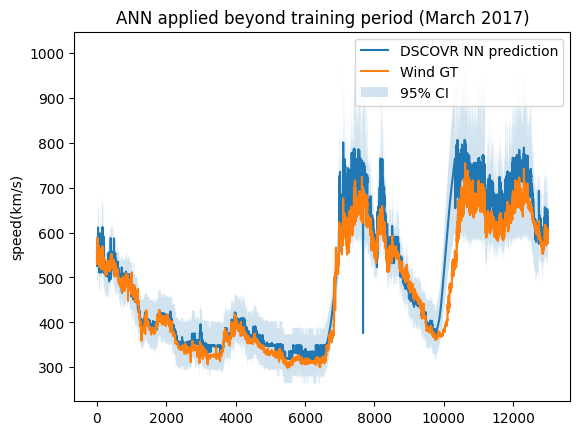

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten the upper and lower bounds
upper_March_flat = np.ravel(upper_March)
lower_March_flat = np.ravel(lower_March)

# Plotting predictions
plt.plot(Predictions_March_, label='DSCOVR NN prediction')

# Plotting confidence interval
plt.fill_between(range(len(Predictions_March_)), upper_March_flat, lower_March_flat, alpha=0.2, label='95% CI')

# Plotting actual values
plt.plot(Wind_input_March_warped_, label='Wind GT')

plt.title('ANN applied beyond training period (March 2017)')
plt.ylabel('speed(km/s)')
plt.legend()
plt.savefig('CI_speed_March_DSCOVR_NN_prediction_and_Wind_GT_2017_2.png')
plt.show()


In [45]:
mask_March=Predictions_March_ >= 1
Predictions_March=Predictions_March_[mask_March]
#Wind_input_March_warped_2=Wind_input_March_warped.reshape(-1,1)
Wind_input_March_warped=Wind_input_March_warped_[mask_March]

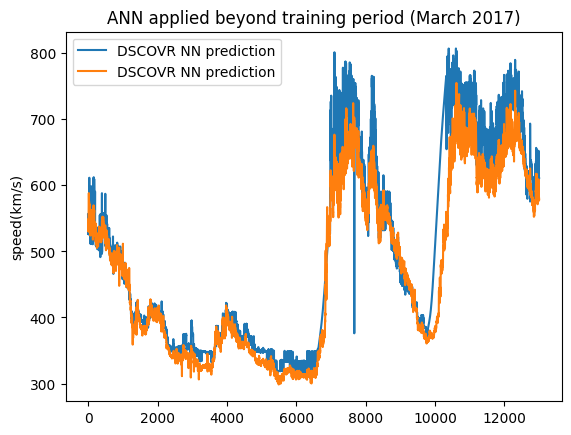

In [46]:
plt.plot(Predictions_March, label='DSCOVR NN prediction')
plt.plot(Wind_input_March_warped, label='DSCOVR NN prediction')
#plt.plot(Wind_input_March_warped, label='Wind GT')
plt.title('ANN applied beyond training period (March 2017)')
#plt.savefig('speed_March_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

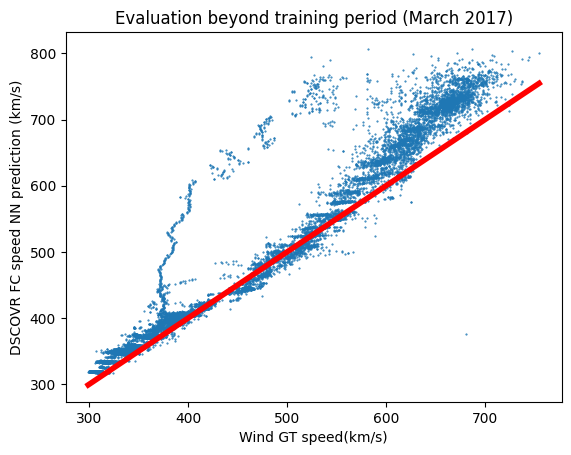

In [47]:
plt.plot(Wind_input_March_warped, Predictions_March, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (March 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped)],[np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped)], color='red', linewidth=4)
#plt.savefig('speed-March_prediction_2017.png')

Mean err %:  31.760977727005844
Median err %:  17.834280598800802
stddev: 39.439758000794036


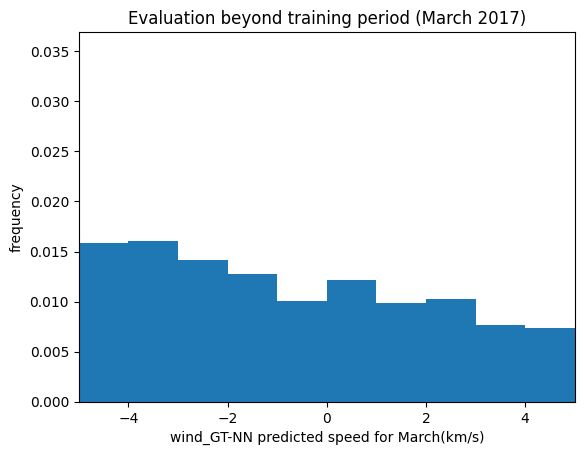

In [48]:
perr_NN_March = 100.*(Wind_input_March_warped-Predictions_March)/Wind_input_March_warped
tk_NN_March=np.where(Wind_input_March_warped > 0.1)
arr_perr_NN_March = (perr_NN_March)[tk_NN_March]
arr_regular_NN_March=(Wind_input_March_warped-Predictions_March)
m_NN_March=np.mean((arr_regular_NN_March))
sd_NN_March=np.std((arr_regular_NN_March))


plt.hist(arr_regular_NN_March, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_March, color='k', linestyle='dashed')
plt.axvline(m_NN_March+sd_NN_March, color='y', linestyle='dashed')
plt.axvline(m_NN_March-sd_NN_March, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.title('Evaluation beyond training period (March 2017)')
plt.xlabel('wind_GT-NN predicted speed for March(km/s)')
plt.ylabel('frequency')
#plt.savefig('Error-speed-March_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_March)))
print('Median err %: ', np.median(abs(arr_regular_NN_March)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_March)

## April

In [49]:
Wind_input_March_warped=Wind_input_March_warped.reshape(-1,1)
Wind_input_March_warped_final=TargetVarScalerFit.transform(Wind_input_March_warped)

mask_March_flat = mask_March.flatten()

# Now use the flattened mask for indexing
DSCOVR_input_March_final = DSCOVR_input_March_final[mask_March_flat]

In [50]:
DSCOVR_input_April, Wind_input_April=input_prep_func(ddata, Wind_speed.values, 49000, 65000)
query1_April, template_April, alignment_wd_April, ind_April=DTW_function(wdata, ddata, 49000, 65000)
Wind_input_April_warped_=Wind_input_April[ind_April]

In [51]:
# Generating the standardized values of DSCOVR_input and Wind_input for April
DSCOVR_input_April_final=PredictorScalerFit.transform(DSCOVR_input_April)
#Wind_input_April_warped_final=TargetVarScalerFit.transform(Wind_input_April_warped)

In [52]:
prediction_distribution_April = bnn_model_full_Jan_Feb(DSCOVR_input_April_final)
prediction_mean_April = prediction_distribution_April.mean().numpy().tolist()
prediction_stdv_April = prediction_distribution_April.stddev().numpy()


Predictions_April_ = TargetVarScalerFit.inverse_transform(prediction_mean_April)
#Wind_input_March_warped_2=Wind_input_March_warped.reshape(-1,1)
#Wind_input_test_orig_March = TargetVarScalerFit.inverse_transform(Wind_input_March_warped_2)
#Test_Data_March = PredictorScalerFit.inverse_transform(DSCOVR_input_March_final)
Predictions_April_

array([[604.49332154],
       [607.2191267 ],
       [608.29770222],
       ...,
       [391.46708404],
       [390.97881654],
       [390.86696145]])

In [53]:
prediction_stdv_April_=prediction_stdv_April*TargetVarScalerFit.scale_

# The 95% CI is computed as mean ± (1.96 * stdv)
upper_April = (Predictions_April_ + (1.96 * prediction_stdv_April_)).tolist()
lower_April = (Predictions_April_ - (1.96 * prediction_stdv_April_)).tolist()
prediction_stdv_April_ = prediction_stdv_April_.tolist()


sample=10
    
for idx in range(sample):
    print(
        f"Prediction mean: {round(Predictions_April_[idx][0], 2)}, "
        f"stddev: {round(prediction_stdv_April_[idx][0], 2)}, "
        f"95% CI: [{round(upper_April[idx][0], 2)} - {round(lower_April[idx][0], 2)}]"
        f" - Actual: {Wind_input_April_warped_[idx]}"
    )


Prediction mean: 604.49, stddev: 42.34, 95% CI: [687.47 - 521.51] - Actual: [585.007]
Prediction mean: 607.22, stddev: 42.82, 95% CI: [691.15 - 523.29] - Actual: [578.551]
Prediction mean: 608.3, stddev: 43.01, 95% CI: [692.59 - 524.01] - Actual: [575.441]
Prediction mean: 605.61, stddev: 42.52, 95% CI: [688.95 - 522.28] - Actual: [574.519]
Prediction mean: 606.21, stddev: 42.55, 95% CI: [689.6 - 522.82] - Actual: [572.29]
Prediction mean: 605.21, stddev: 42.4, 95% CI: [688.31 - 522.1] - Actual: [571.8505]
Prediction mean: 604.89, stddev: 42.3, 95% CI: [687.8 - 521.98] - Actual: [572.0925]
Prediction mean: 605.65, stddev: 42.48, 95% CI: [688.91 - 522.4] - Actual: [569.531]
Prediction mean: 605.02, stddev: 42.32, 95% CI: [687.96 - 522.07] - Actual: [572.5565]
Prediction mean: 604.29, stddev: 42.11, 95% CI: [686.83 - 521.76] - Actual: [572.5565]


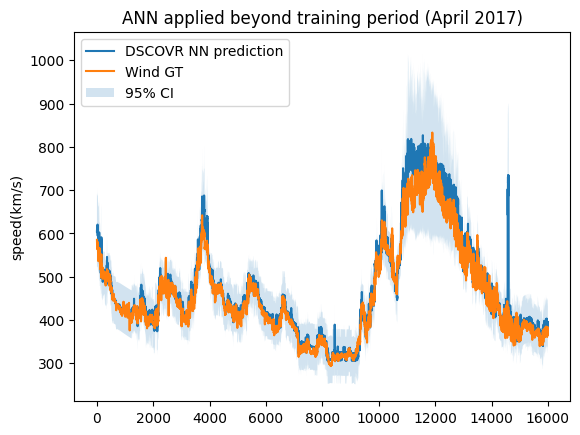

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten the upper and lower bounds
upper_April_flat = np.ravel(upper_April)
lower_April_flat = np.ravel(lower_April)



# Plotting predictions
plt.plot(Predictions_April_, label='DSCOVR NN prediction')

# Plotting confidence interval
plt.fill_between(range(len(Predictions_April_)), upper_April_flat, lower_April_flat, alpha=0.2, label='95% CI')


# Plotting actual values
plt.plot(Wind_input_April_warped_, label='Wind GT')

plt.title('ANN applied beyond training period (April 2017)')
plt.ylabel('speed(km/s)')
#plt.ylim(0,50)
plt.legend(loc='center left', bbox_to_anchor=(-0.001,0.89))
#plt.savefig('CI_speed_April_DSCOVR_NN_prediction_and_Wind_GT_2017.png')
plt.show()


In [56]:
mask_April=Predictions_April_ >= 1
Predictions_April=Predictions_April_[mask_April]
#Wind_input_March_warped_2=Wind_input_March_warped.reshape(-1,1)
Wind_input_April_warped=Wind_input_April_warped_[mask_April]

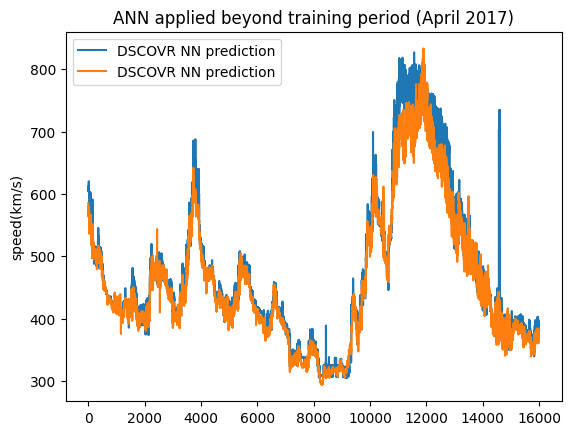

In [57]:
plt.plot(Predictions_April, label='DSCOVR NN prediction')
plt.plot(Wind_input_April_warped, label='DSCOVR NN prediction')
#plt.plot(Wind_input_March_warped, label='Wind GT')
plt.title('ANN applied beyond training period (April 2017)')
#plt.savefig('speed_April_DSCOVR_NN_prediction_and_Wind GT_2017.png')
#plt.xlabel('')
plt.ylabel('speed(km/s)')
plt.legend()

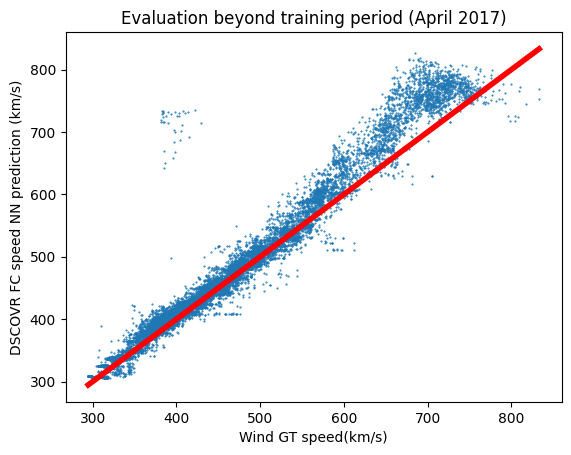

In [58]:
plt.plot(Wind_input_April_warped, Predictions_April, marker='.', markersize=1, linestyle = ' ')
plt.xlabel("Wind GT speed(km/s)")
plt.ylabel("DSCOVR FC speed NN prediction (km/s)")
plt.title('Evaluation beyond training period (April 2017)')
#plt.xlim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
#plt.ylim(np.amin(Wind_input_March_warped), np.amax(Wind_input_March_warped))
plt.plot([np.amin(Wind_input_April_warped), np.amax(Wind_input_April_warped)],[np.amin(Wind_input_April_warped), np.amax(Wind_input_April_warped)], color='red', linewidth=4)
#plt.savefig('speed-March_prediction_2017.png')

Mean err %:  17.182927351637108
Median err %:  10.402466877168877
stddev: 25.955817233784877


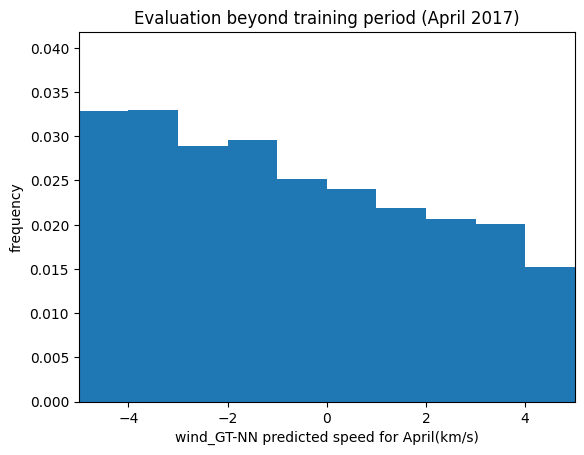

In [59]:
perr_NN_April = 100.*(Wind_input_April_warped-Predictions_April)/Wind_input_April_warped
tk_NN_April=np.where(Wind_input_April_warped > 0.1)
arr_perr_NN_April = (perr_NN_April)[tk_NN_April]
arr_regular_NN_April=(Wind_input_April_warped-Predictions_April)
m_NN_April=np.mean((arr_regular_NN_April))
sd_NN_April=np.std((arr_regular_NN_April))


plt.hist(arr_regular_NN_April, bins=np.arange(200)-100, density = 'true')

plt.axvline(m_NN_April, color='k', linestyle='dashed')
plt.axvline(m_NN_April+sd_NN_April, color='y', linestyle='dashed')
plt.axvline(m_NN_April-sd_NN_April, color='y', linestyle='dashed')

plt.xlim(-5,5)
#plt.yscale('log')
plt.title('Evaluation beyond training period (April 2017)')
plt.xlabel('wind_GT-NN predicted speed for April(km/s)')
plt.ylabel('frequency')
#plt.savefig('Error-speed-April_prediction_2017.png')

print('Mean err %: ', np.mean(abs(arr_regular_NN_April)))
print('Median err %: ', np.median(abs(arr_regular_NN_April)))
#print('Most probable err %: ', np.mode(abs(arr_regular_NN_March)))

print('stddev:',sd_NN_April)